Crypto Arima Data Exploration

Martha McQuillan 1/12/2026

In [1]:
import sys
from pathlib import Path

# add project root to Python path
PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))

BTC series:
Date
2018-01-01    13657.200195
2018-01-02    14982.099609
2018-01-03    15201.000000
2018-01-04    15599.200195
2018-01-05    17429.500000
Freq: D, Name: BTC-USD, dtype: float64 

Prices DF:
                 btc_usd     eth_usd
Date                                
2018-01-01  13657.200195  772.640991
2018-01-02  14982.099609  884.443970
2018-01-03  15201.000000  962.719971
2018-01-04  15599.200195  980.921997
2018-01-05  17429.500000  997.719971 

Saved prices to: /Users/marthamcquillan/Projects/crypto-arima/data/btc_eth_prices.csv 

Loaded DF matches shape: (2935, 2) 

Returns DF:
            btc_usd_logret  eth_usd_logret
date                                      
2018-01-02        0.092589        0.135145
2018-01-03        0.014505        0.084803
2018-01-04        0.025858        0.018730
2018-01-05        0.110945        0.016980
2018-01-06        0.005578        0.043117 



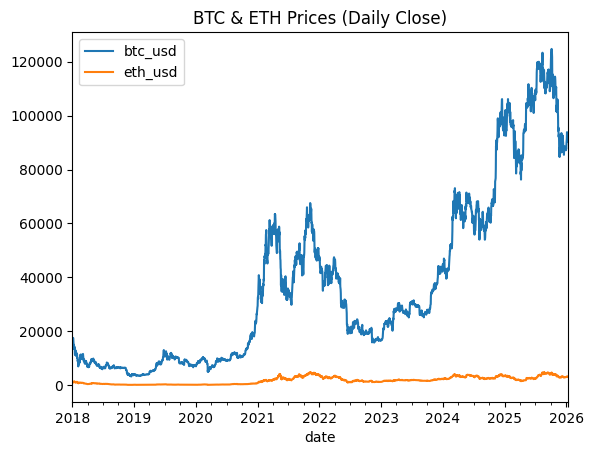

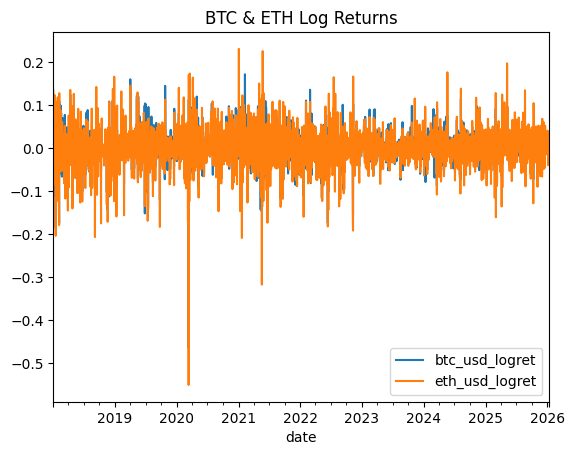

In [4]:
import matplotlib.pyplot as plt

from src.data_loader import (
    fetch_yahoo,
    make_price_df,
    compute_log_returns,
    save_prices_csv,
    load_prices_csv,
)

# 1) Fetch BTC-USD Series
btc = fetch_yahoo("BTC-USD", start="2018-01-01")
print("BTC series:")
print(btc.head(), "\n")

# 2) Fetch both BTC-USD and ETH-USD
prices = make_price_df(
    {"btc_usd": "BTC-USD", "eth_usd": "ETH-USD"},
    start="2018-01-01",
)
print("Prices DF:")
print(prices.head(), "\n")

# 3) Save prices to (project-root/data/)
path = save_prices_csv(prices, filename="btc_eth_prices.csv")
print("Saved prices to:", path, "\n")

# 4) Load them back
prices_loaded = load_prices_csv("btc_eth_prices.csv")
print("Loaded DF matches shape:", prices_loaded.shape, "\n")

# 5) Compute log returns
returns = compute_log_returns(prices_loaded)
print("Returns DF:")
print(returns.head(), "\n")

# 6) Plots of daily returns, and log returns
prices_loaded.plot(title="BTC & ETH Prices (Daily Close)")
plt.show()

returns.plot(title="BTC & ETH Log Returns")
plt.show()

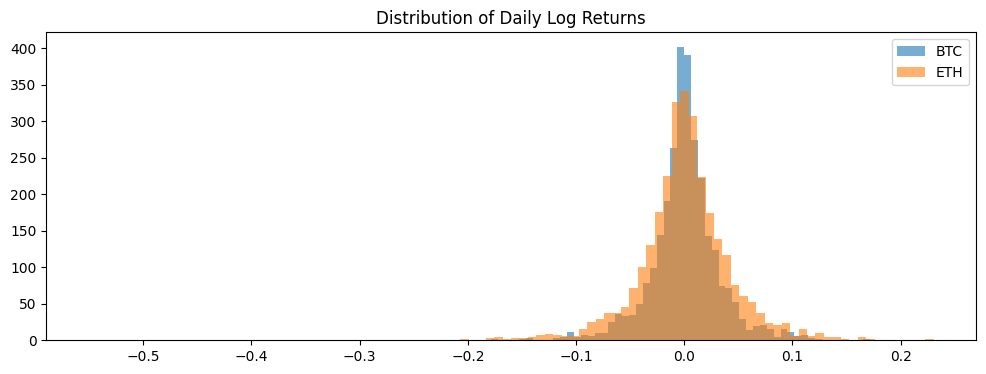

In [6]:
plt.figure(figsize=(12, 4))
plt.hist(returns["btc_usd_logret"], bins=100, alpha=0.6, label="BTC")
plt.hist(returns["eth_usd_logret"], bins=100, alpha=0.6, label="ETH")
plt.title("Distribution of Daily Log Returns")
plt.legend()
plt.show()

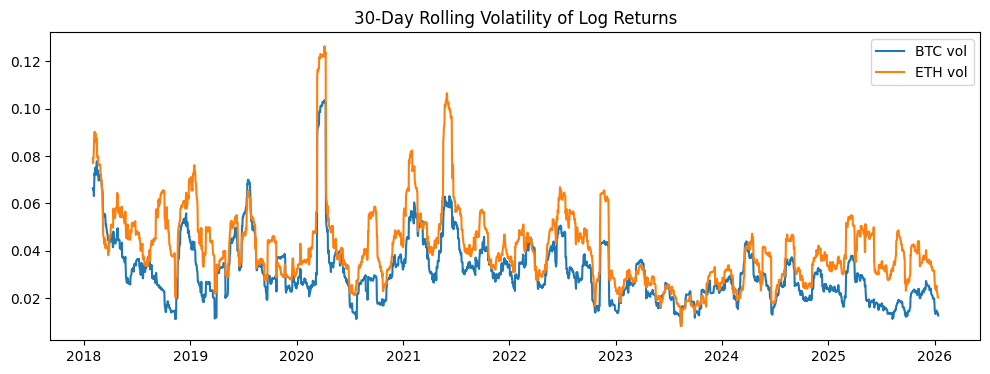

In [8]:
rolling_vol = returns.rolling(30).std()

plt.figure(figsize=(12, 4))
plt.plot(rolling_vol.index, rolling_vol["btc_usd_logret"], label="BTC vol")
plt.plot(rolling_vol.index, rolling_vol["eth_usd_logret"], label="ETH vol")
plt.title("30-Day Rolling Volatility of Log Returns")
plt.legend()
plt.show()

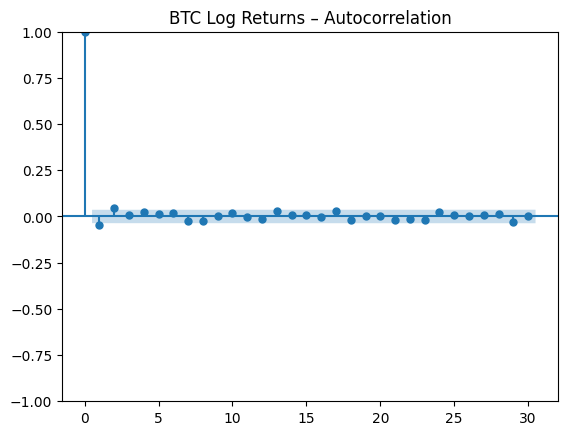

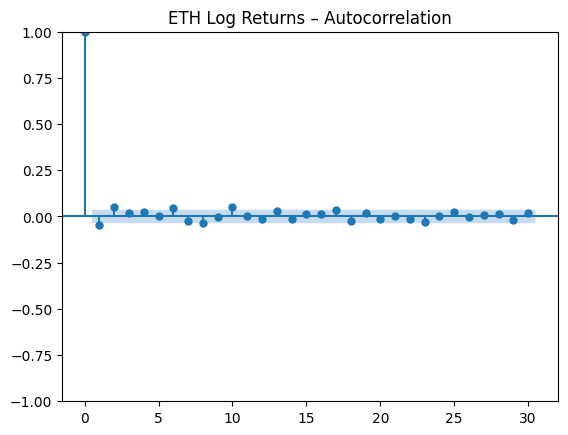

In [9]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(returns["btc_usd_logret"], lags=30)
plt.title("BTC Log Returns – Autocorrelation")
plt.show()

plot_acf(returns["eth_usd_logret"], lags=30)
plt.title("ETH Log Returns – Autocorrelation")
plt.show()

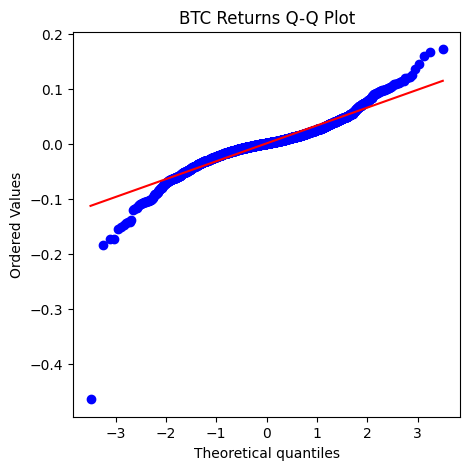

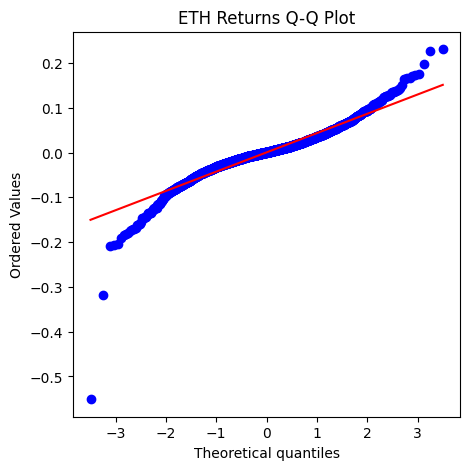

In [10]:
import scipy.stats as stats

plt.figure(figsize=(5, 5))
stats.probplot(returns["btc_usd_logret"], dist="norm", plot=plt)
plt.title("BTC Returns Q-Q Plot")
plt.show()

plt.figure(figsize=(5, 5))
stats.probplot(returns["eth_usd_logret"], dist="norm", plot=plt)
plt.title("ETH Returns Q-Q Plot")
plt.show()
